# NB05: Genomic Context Analysis

**Goal**: Analyze the genomic neighborhood of truly dark genes — operon context via cofitness, proximity to mobile elements, and ICA module guilt-by-association.

**Input**: NB01-NB03 outputs, fitness_modules matrices and annotations

**Output**: `data/genomic_context.tsv`, context summary figures

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import os
import glob
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

OUT = '../data'
FIG = '../figures'
FM_DIR = '../../fitness_modules/data'
os.makedirs(FIG, exist_ok=True)
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})

## 1. Load Data

In [2]:
td = pd.read_csv(f'{OUT}/truly_dark_genes.tsv', sep='\t')
clue = pd.read_csv(f'{OUT}/truly_dark_clue_matrix.tsv', sep='\t')
gene_props = pd.read_csv(f'{OUT}/gene_properties.tsv', sep='\t')
print(f'Truly dark genes: {len(td):,}')
print(f'Gene properties: {len(gene_props):,} (TD + AL)')

# Get list of organisms with fitness module data (32 ICA organisms)
fm_orgs = sorted(set(
    Path(f).stem.replace('_genes', '') 
    for f in glob.glob(f'{FM_DIR}/annotations/*_genes.csv')
))
print(f'Fitness module organisms: {len(fm_orgs)}')

# Which TD genes are in ICA organisms?
td_in_ica = td[td['orgId'].isin(fm_orgs)]
print(f'TD genes in ICA organisms: {len(td_in_ica):,} / {len(td):,}')

Truly dark genes: 6,427
Gene properties: 39,532 (TD + AL)
Fitness module organisms: 32
TD genes in ICA organisms: 4,394 / 6,427


## 2. Neighbor Gene Annotations

For each truly dark gene, check what the flanking genes are annotated as. Look for mobile elements (transposases, integrases, phage) nearby.

In [3]:
# Load gene annotations for all ICA organisms and find neighbors
mobile_keywords = ['transpos', 'integrase', 'recombinase', 'phage', 'IS\d', 
                    'insertion', 'mobile', 'conjugat', 'plasmid']
mobile_pattern = '|'.join(mobile_keywords)

neighbor_results = []

for org in fm_orgs:
    gene_file = f'{FM_DIR}/annotations/{org}_genes.csv'
    if not os.path.exists(gene_file):
        continue
    
    genes = pd.read_csv(gene_file)
    genes['locusId'] = genes['locusId'].astype(str)
    
    # Get TD genes for this organism
    td_org = td[td['orgId'] == org]['locusId'].astype(str).tolist()
    if not td_org:
        continue
    
    # Sort genes by scaffold and position
    genes = genes.sort_values(['scaffoldId', 'begin']).reset_index(drop=True)
    
    for td_locus in td_org:
        idx = genes.index[genes['locusId'] == td_locus].tolist()
        if not idx:
            continue
        i = idx[0]
        scaffold = genes.loc[i, 'scaffoldId']
        
        # Check 2 genes upstream and 2 downstream (same scaffold)
        for offset in [-2, -1, 1, 2]:
            j = i + offset
            if 0 <= j < len(genes) and genes.loc[j, 'scaffoldId'] == scaffold:
                neighbor_desc = str(genes.loc[j, 'desc'])
                is_mobile = bool(pd.Series([neighbor_desc]).str.contains(
                    mobile_pattern, case=False, na=False).iloc[0])
                neighbor_results.append({
                    'orgId': org,
                    'locusId': td_locus,
                    'offset': offset,
                    'neighbor_locusId': str(genes.loc[j, 'locusId']),
                    'neighbor_desc': neighbor_desc,
                    'neighbor_is_mobile': is_mobile,
                    'neighbor_is_hyp': 'hypothetical' in neighbor_desc.lower()
                })

neighbors = pd.DataFrame(neighbor_results)
print(f'Neighbor annotations: {len(neighbors):,} entries for {neighbors[["orgId","locusId"]].drop_duplicates().shape[0]} TD genes')

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_63547/4265516612.py:2: SyntaxWarning: invalid escape sequence '\d'
  mobile_keywords = ['transpos', 'integrase', 'recombinase', 'phage', 'IS\d',


Neighbor annotations: 17,548 entries for 4394 TD genes


In [4]:
# Summarize mobile element proximity
td_mobile = neighbors.groupby(['orgId', 'locusId'])['neighbor_is_mobile'].any().reset_index()
td_mobile.columns = ['orgId', 'locusId', 'near_mobile_element']

n_near_mobile = td_mobile['near_mobile_element'].sum()
n_total = len(td_mobile)
print(f'TD genes near mobile elements (within 2 genes): {n_near_mobile} / {n_total} ({n_near_mobile/n_total*100:.1f}%)')

# Hypothetical neighbors
td_hyp_neighbors = neighbors.groupby(['orgId', 'locusId'])['neighbor_is_hyp'].mean().reset_index()
td_hyp_neighbors.columns = ['orgId', 'locusId', 'frac_hyp_neighbors']
print(f'Mean fraction of neighbors that are hypothetical: {td_hyp_neighbors["frac_hyp_neighbors"].mean():.2f}')

# Most common mobile element types near TD genes
mobile_neighbors = neighbors[neighbors['neighbor_is_mobile']]
if len(mobile_neighbors) > 0:
    print(f'\nMobile element types near TD genes:')
    print(mobile_neighbors['neighbor_desc'].value_counts().head(15).to_string())

TD genes near mobile elements (within 2 genes): 526 / 4394 (12.0%)
Mean fraction of neighbors that are hypothetical: 0.41

Mobile element types near TD genes:
neighbor_desc
transposase                                                        62
integrase                                                          37
ISSod4, transposase (NCBI ptt file)                                22
DUF2080 family transposase-associated protein                      22
transposase (NCBI ptt file)                                        21
ISSod1, transposase OrfB (NCBI ptt file)                           19
Transposase and inactivated derivatives                            17
ISSod1, transposase OrfA (NCBI ptt file)                           17
site-specific integrase                                            14
phage integrase family protein (RefSeq)                            12
conserved protein found in conjugate transposon (NCBI ptt file)    12
Phage protein                                            

## 3. Operon Context via Cofitness

For TD genes with fitness data, check cofitness with adjacent genes (|r| >= 0.3 = operon proxy).

In [5]:
# For each organism, load fitness matrix and compute cofitness between
# TD genes and their immediate neighbors
COFIT_THRESHOLD = 0.3
operon_results = []

for org in fm_orgs:
    fit_file = f'{FM_DIR}/matrices/{org}_fitness_matrix.csv'
    gene_file = f'{FM_DIR}/annotations/{org}_genes.csv'
    if not os.path.exists(fit_file) or not os.path.exists(gene_file):
        continue
    
    td_org = td[td['orgId'] == org]['locusId'].astype(str).tolist()
    if not td_org:
        continue
    
    # Load fitness matrix
    fit = pd.read_csv(fit_file, index_col=0)
    fit.index = fit.index.astype(str)
    
    # Load gene order
    genes = pd.read_csv(gene_file)
    genes['locusId'] = genes['locusId'].astype(str)
    genes = genes.sort_values(['scaffoldId', 'begin']).reset_index(drop=True)
    
    for td_locus in td_org:
        if td_locus not in fit.index:
            continue
        
        idx = genes.index[genes['locusId'] == td_locus].tolist()
        if not idx:
            continue
        i = idx[0]
        scaffold = genes.loc[i, 'scaffoldId']
        
        td_fitness = fit.loc[td_locus]
        
        # Check immediate neighbors
        for offset in [-1, 1]:
            j = i + offset
            if 0 <= j < len(genes) and genes.loc[j, 'scaffoldId'] == scaffold:
                nb_locus = str(genes.loc[j, 'locusId'])
                if nb_locus in fit.index:
                    nb_fitness = fit.loc[nb_locus]
                    # Compute Pearson correlation
                    valid = td_fitness.notna() & nb_fitness.notna()
                    if valid.sum() >= 10:
                        r = td_fitness[valid].corr(nb_fitness[valid])
                        operon_results.append({
                            'orgId': org,
                            'locusId': td_locus,
                            'neighbor_locusId': nb_locus,
                            'offset': offset,
                            'cofitness': r,
                            'in_operon': abs(r) >= COFIT_THRESHOLD,
                            'neighbor_desc': str(genes.loc[j, 'desc'])
                        })

operons = pd.DataFrame(operon_results)
print(f'Cofitness pairs computed: {len(operons):,}')
print(f'TD genes with cofitness data: {operons[["orgId","locusId"]].drop_duplicates().shape[0]}')

if len(operons) > 0:
    in_operon = operons.groupby(['orgId', 'locusId'])['in_operon'].any().reset_index()
    n_operon = in_operon['in_operon'].sum()
    print(f'\nTD genes in operons (|r| >= {COFIT_THRESHOLD}): {n_operon} / {len(in_operon)} ({n_operon/len(in_operon)*100:.1f}%)')
    
    print(f'\nCofitness distribution:')
    print(f'  mean |r| = {operons["cofitness"].abs().mean():.3f}')
    print(f'  median |r| = {operons["cofitness"].abs().median():.3f}')
    print(f'  |r| >= 0.5: {(operons["cofitness"].abs() >= 0.5).sum()}')
    print(f'  |r| >= 0.7: {(operons["cofitness"].abs() >= 0.7).sum()}')

Cofitness pairs computed: 6,222
TD genes with cofitness data: 3535

TD genes in operons (|r| >= 0.3): 916 / 3535 (25.9%)

Cofitness distribution:
  mean |r| = 0.185
  median |r| = 0.128
  |r| >= 0.5: 443
  |r| >= 0.7: 170


In [6]:
# Show top operon-like pairs (highest cofitness)
if len(operons) > 0:
    top_operon = operons.nlargest(20, 'cofitness')
    print('Top 20 cofitness pairs (potential operons):')
    for _, row in top_operon.iterrows():
        print(f'  {row["orgId"]} {row["locusId"]} <-> {row["neighbor_locusId"]}: r={row["cofitness"]:.3f} [{row["neighbor_desc"][:60]}]')

Top 20 cofitness pairs (potential operons):
  Methanococcus_S2 MMP_RS01310 <-> MMP_RS01305: r=0.991 [hypothetical protein]
  Methanococcus_S2 MMP_RS01305 <-> MMP_RS01310: r=0.991 [hypothetical protein]
  SynE Synpcc7942_2484 <-> Synpcc7942_2485: r=0.991 [hypothetical protein]
  SynE Synpcc7942_0008 <-> Synpcc7942_0007: r=0.990 [hypothetical protein]
  Methanococcus_S2 MMP_RS05055 <-> MMP_RS05060: r=0.987 [AAA family ATPase]
  Methanococcus_S2 MMP_RS01285 <-> MMP_RS01290: r=0.986 [class III signal peptide-containing protein]
  Dino 3610486 <-> 3610485: r=0.982 [glycosyl transferase group 1 (RefSeq)]
  Methanococcus_S2 MMP_RS01915 <-> MMP_RS01920: r=0.980 [glycosyltransferase family 2 protein]
  Methanococcus_S2 MMP_RS01915 <-> MMP_RS01910: r=0.980 [UDP-N-acetylglucosamine 2-epimerase (non-hydrolyzing)]
  Phaeo GFF1821 <-> GFF1822: r=0.979 [Predicted ATPase]
  Methanococcus_S2 MMP_RS01295 <-> MMP_RS01290: r=0.978 [class III signal peptide-containing protein]
  WCS417 GFF3924 <-> GFF3923:

## 4. Condition-Class Enrichment

What experimental conditions produce the strongest fitness effects for truly dark genes?

In [7]:
# Condition class distribution for truly dark vs annotation-lag
al = pd.read_csv(f'{OUT}/annotation_lag_genes.tsv', sep='\t')

# Genes with strong fitness (|f| >= 2)
td_strong = td[td['max_abs_fit'] >= 2.0]
al_strong = al[al['max_abs_fit'] >= 2.0]

print(f'Genes with strong fitness (|f| >= 2):')
print(f'  Truly dark: {len(td_strong):,} / {len(td):,} ({len(td_strong)/len(td)*100:.1f}%)')
print(f'  Annotation-lag: {len(al_strong):,} / {len(al):,} ({len(al_strong)/len(al)*100:.1f}%)')

# Condition class distribution for strong-fitness genes
td_cond = td_strong['top_condition_class'].value_counts()
al_cond = al_strong['top_condition_class'].value_counts()

# Combine into comparison table
all_conditions = sorted(set(td_cond.index) | set(al_cond.index))
cond_comp = pd.DataFrame({
    'truly_dark': [td_cond.get(c, 0) for c in all_conditions],
    'annotation_lag': [al_cond.get(c, 0) for c in all_conditions]
}, index=all_conditions)
cond_comp['td_pct'] = cond_comp['truly_dark'] / cond_comp['truly_dark'].sum() * 100
cond_comp['al_pct'] = cond_comp['annotation_lag'] / cond_comp['annotation_lag'].sum() * 100
cond_comp['enrichment'] = cond_comp['td_pct'] / cond_comp['al_pct'].replace(0, np.nan)
cond_comp = cond_comp.sort_values('enrichment', ascending=False)

print(f'\nCondition-class enrichment (TD vs AL, strong fitness genes):')
print(f'{"Condition":<25} {"TD":>5} {"AL":>5} {"TD%":>6} {"AL%":>6} {"Enrich":>7}')
print('-' * 60)
for cond, row in cond_comp.iterrows():
    if pd.notna(cond) and cond != '':
        print(f'{str(cond)[:25]:<25} {row["truly_dark"]:>5} {row["annotation_lag"]:>5} {row["td_pct"]:>5.1f}% {row["al_pct"]:>5.1f}% {row["enrichment"]:>6.2f}x')

Genes with strong fitness (|f| >= 2):
  Truly dark: 902 / 6,427 (14.0%)
  Annotation-lag: 4,677 / 33,105 (14.1%)

Condition-class enrichment (TD vs AL, strong fitness genes):
Condition                    TD    AL    TD%    AL%  Enrich
------------------------------------------------------------
nutrient t2                30.0   1.0   5.1%   0.0% 181.28x
cpg                         1.0   1.0   0.2%   0.0%   6.04x
pye                         1.0   1.0   0.2%   0.0%   6.04x
marine broth                4.0   6.0   0.7%   0.2%   4.03x
plant                       9.0  19.0   1.5%   0.5%   2.86x
respiratory growth          6.0  20.0   1.0%   0.6%   1.81x
reactor                     1.0   4.0   0.2%   0.1%   1.51x
metal limitation            1.0   4.0   0.2%   0.1%   1.51x
nitrogen source            72.0 343.0  12.3%   9.7%   1.27x
nutrient                    7.0  35.0   1.2%   1.0%   1.21x
control                     2.0  12.0   0.3%   0.3%   1.01x
supernatant                 2.0  15.0   0.3%

In [8]:
# Fisher's exact test for stress enrichment (H2)
stress_conditions = ['stress', 'metal', 'oxidative', 'pH', 'osmotic', 'temperature']

td_stress = td_strong['top_condition_class'].str.lower().isin(
    [s.lower() for s in stress_conditions]).sum()
td_nonstress = len(td_strong) - td_stress
al_stress = al_strong['top_condition_class'].str.lower().isin(
    [s.lower() for s in stress_conditions]).sum()
al_nonstress = len(al_strong) - al_stress

table = [[td_stress, td_nonstress], [al_stress, al_nonstress]]
odds_ratio, pval = stats.fisher_exact(table)
print(f'H2: Stress condition enrichment')
print(f'  TD stress: {td_stress} / {len(td_strong)} ({td_stress/len(td_strong)*100:.1f}%)')
print(f'  AL stress: {al_stress} / {len(al_strong)} ({al_stress/len(al_strong)*100:.1f}%)')
print(f'  Fisher exact: OR={odds_ratio:.3f}, p={pval:.3f}')
if odds_ratio > 1.5 and pval < 0.05:
    print(f'  => H2 SUPPORTED: TD genes enriched in stress conditions')
else:
    print(f'  => H2 not supported at pre-registered thresholds (OR >= 1.5, p < 0.05)')

H2: Stress condition enrichment
  TD stress: 259 / 902 (28.7%)
  AL stress: 2020 / 4677 (43.2%)
  Fisher exact: OR=0.530, p=0.000
  => H2 not supported at pre-registered thresholds (OR >= 1.5, p < 0.05)


## 5. Visualization

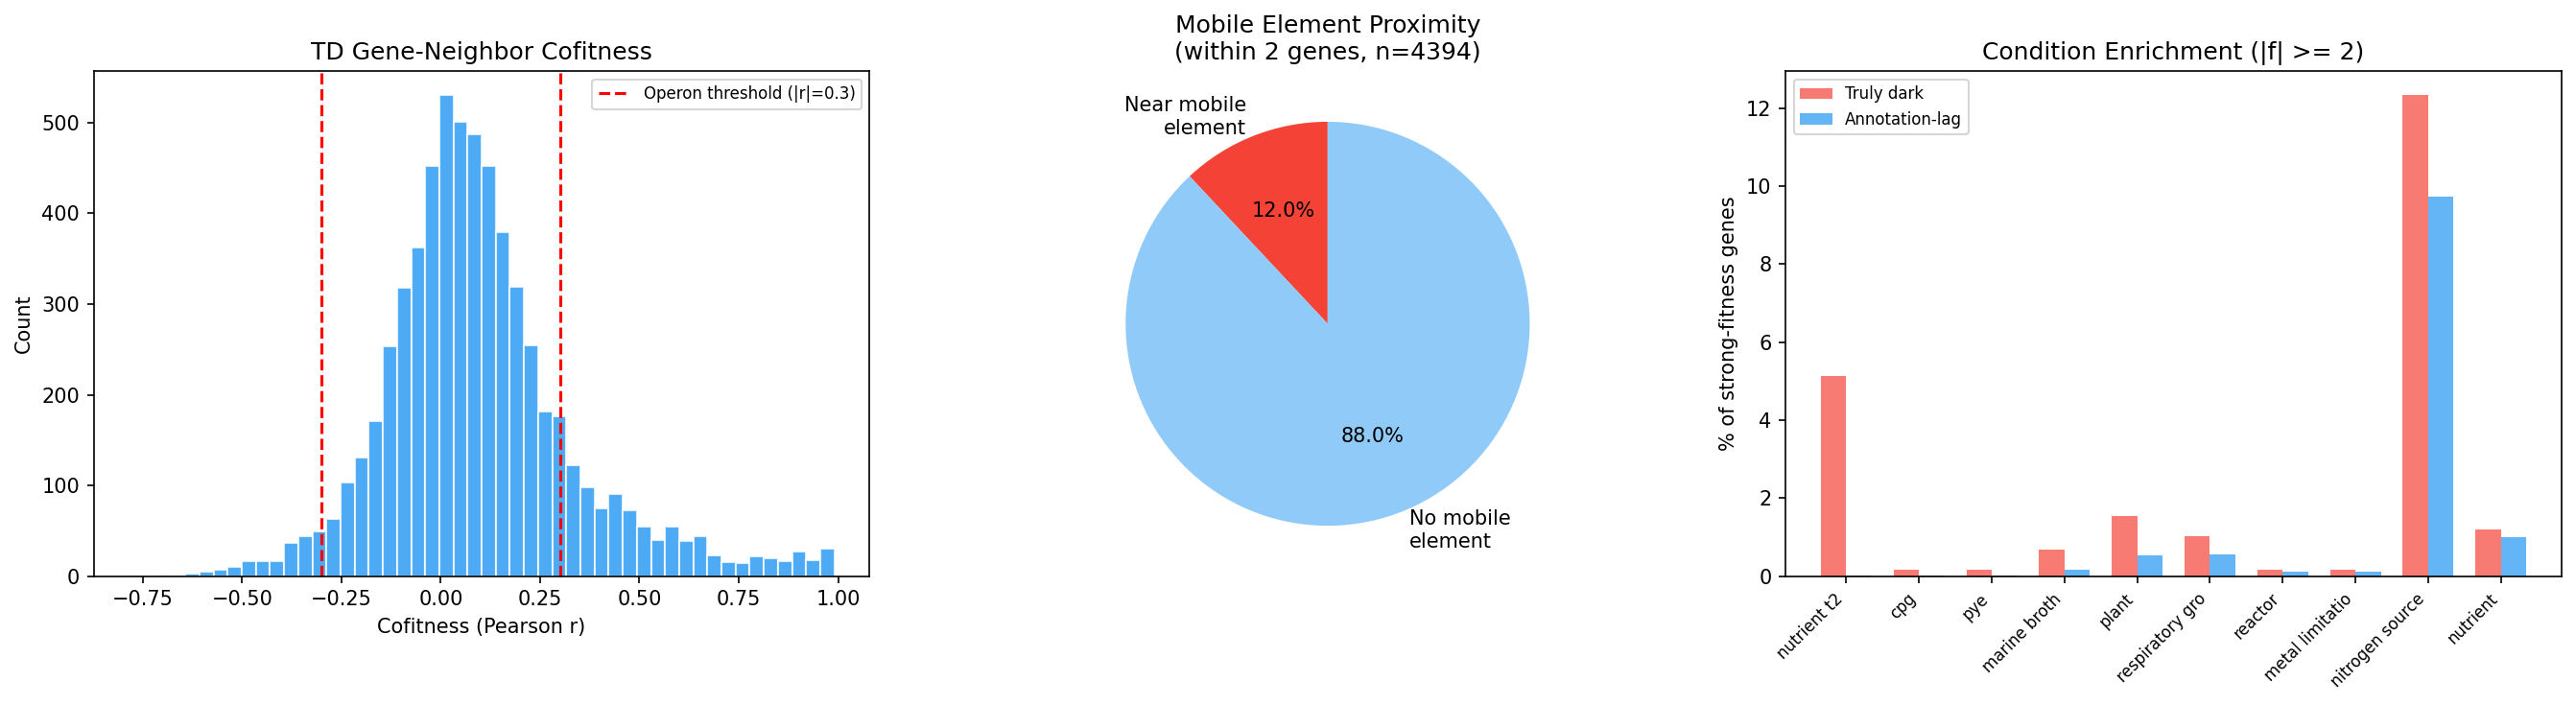

Saved: fig08_genomic_context.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: cofitness distribution
ax = axes[0]
if len(operons) > 0:
    ax.hist(operons['cofitness'], bins=50, color='#2196F3', edgecolor='white', alpha=0.8)
    ax.axvline(COFIT_THRESHOLD, color='red', ls='--', label=f'Operon threshold (|r|={COFIT_THRESHOLD})')
    ax.axvline(-COFIT_THRESHOLD, color='red', ls='--')
    ax.set_xlabel('Cofitness (Pearson r)')
    ax.set_ylabel('Count')
    ax.set_title('TD Gene-Neighbor Cofitness')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'No cofitness data', ha='center', va='center', transform=ax.transAxes)

# Middle: mobile element proximity
ax = axes[1]
if len(td_mobile) > 0:
    vals = [td_mobile['near_mobile_element'].sum(), len(td_mobile) - td_mobile['near_mobile_element'].sum()]
    labels = ['Near mobile\nelement', 'No mobile\nelement']
    colors = ['#f44336', '#90CAF9']
    ax.pie(vals, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    ax.set_title(f'Mobile Element Proximity\n(within 2 genes, n={len(td_mobile)})')

# Right: condition class enrichment
ax = axes[2]
top_conds = cond_comp.head(10)
x = range(len(top_conds))
width = 0.35
ax.bar([i - width/2 for i in x], top_conds['td_pct'], width, label='Truly dark', color='#f44336', alpha=0.7)
ax.bar([i + width/2 for i in x], top_conds['al_pct'], width, label='Annotation-lag', color='#2196F3', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([str(c)[:15] for c in top_conds.index], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('% of strong-fitness genes')
ax.set_title('Condition Enrichment (|f| >= 2)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIG}/fig08_genomic_context.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: fig08_genomic_context.png')

## 6. Build Genomic Context Table

In [10]:
# Merge all context info back to the clue matrix
clue['locusId'] = clue['locusId'].astype(str)

context = clue[['orgId', 'locusId', 'gene_cluster_id', 'n_clues', 'tier']].copy()

# Add mobile element proximity
if len(td_mobile) > 0:
    td_mobile['locusId'] = td_mobile['locusId'].astype(str)
    context = context.merge(td_mobile, on=['orgId', 'locusId'], how='left')
    context['near_mobile_element'] = context['near_mobile_element'].fillna(False)

# Add operon membership
if len(operons) > 0:
    operon_summary = operons.groupby(['orgId', 'locusId']).agg(
        max_cofitness=('cofitness', lambda x: x.abs().max()),
        in_operon=('in_operon', 'any'),
        operon_partner_desc=('neighbor_desc', lambda x: x.iloc[x.reset_index(drop=True).map(lambda v: abs(operons.loc[x.index, 'cofitness'].iloc[0])).idxmax()] if len(x) > 0 else '')
    ).reset_index()
    operon_summary['locusId'] = operon_summary['locusId'].astype(str)
    context = context.merge(operon_summary, on=['orgId', 'locusId'], how='left')
    context['in_operon'] = context['in_operon'].fillna(False)
    context['max_cofitness'] = context['max_cofitness'].fillna(0)

# Add hypothetical neighbor fraction
if len(td_hyp_neighbors) > 0:
    td_hyp_neighbors['locusId'] = td_hyp_neighbors['locusId'].astype(str)
    context = context.merge(td_hyp_neighbors, on=['orgId', 'locusId'], how='left')

context.to_csv(f'{OUT}/genomic_context.tsv', sep='\t', index=False)
print(f'Saved: genomic_context.tsv ({os.path.getsize(f"{OUT}/genomic_context.tsv")/1024:.0f} KB)')
print(f'  Columns: {list(context.columns)}')

Saved: genomic_context.tsv (747 KB)
  Columns: ['orgId', 'locusId', 'gene_cluster_id', 'n_clues', 'tier', 'near_mobile_element', 'max_cofitness', 'in_operon', 'operon_partner_desc', 'frac_hyp_neighbors']


## 7. Summary

In [11]:
print('=== NB05 Complete ===')
print(f'\nGenomic context for {len(td):,} truly dark genes:')
if len(td_mobile) > 0:
    print(f'  Near mobile elements: {n_near_mobile} / {n_total} ({n_near_mobile/n_total*100:.1f}%)')
    print(f'  Mean frac hypothetical neighbors: {td_hyp_neighbors["frac_hyp_neighbors"].mean():.2f}')
if len(operons) > 0:
    print(f'  In operons (|r| >= {COFIT_THRESHOLD}): {n_operon} / {len(in_operon)} ({n_operon/len(in_operon)*100:.1f}%)')
    print(f'  Mean neighbor |cofitness|: {operons["cofitness"].abs().mean():.3f}')
print(f'  Strong fitness TD: {len(td_strong):,} genes')
print(f'\nReady for NB06: Experimental Prioritization')

=== NB05 Complete ===

Genomic context for 6,427 truly dark genes:
  Near mobile elements: 526 / 4394 (12.0%)
  Mean frac hypothetical neighbors: 0.41
  In operons (|r| >= 0.3): 916 / 3535 (25.9%)
  Mean neighbor |cofitness|: 0.185
  Strong fitness TD: 902 genes

Ready for NB06: Experimental Prioritization
